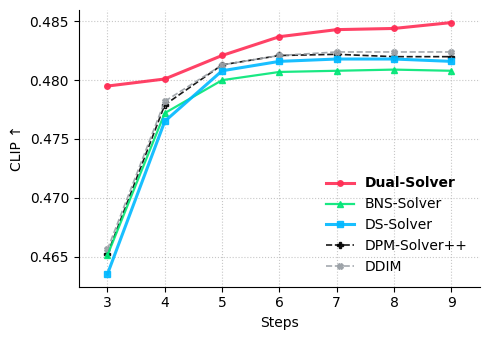

In [1]:
# Apply: DPM-Solver++ = black, Euler = gray. Others unchanged (neon).
# Dual (ours) bold; DS/BNS medium; DPM/Euler dashed.

import matplotlib.pyplot as plt
import numpy as np

steps = np.array([3, 4, 5, 6, 7, 8, 9])
results = {
    "Dual-Solver":    np.array([0.4795,	0.4801,	0.4821,	0.4837,	0.4843,	0.4844,	0.4849]),
    "BNS-Solver":     np.array([0.4651,	0.4772,	0.4800,	0.4807,	0.4808,	0.4809,	0.4808]),
    "DS-Solver":      np.array([0.4635,	0.4765, 0.4808,	0.4816, 0.4818,	0.4818,	0.4816]),
    "DPM-Solver++":   np.array([0.4652,	0.4779,	0.4813,	0.4821,	0.4822,	0.4820,	0.4820]),
    "DDIM":           np.array([0.4656,	0.4782,	0.4813,	0.4821,	0.4824,	0.4824,	0.4824]),
}

style = {
    "Dual-Solver": dict(color="#FF2D55", lw=2.2, ls="-",  marker="o", zorder=3),
    "DS-Solver": dict(color="#00B8FF", lw=2.2, ls="-",  marker="s", zorder=3),
    "BNS-Solver":      dict(color="#00E676", lw=1.6, ls="-",  marker="^", zorder=2),
    "DPM-Solver++":   dict(color="#000000", lw=1.2, ls="--", marker="P", zorder=1),  # black
    "DDIM":          dict(color="#9AA0A6", lw=1.2, ls="--", marker="X", zorder=1),  # gray
}

fig, ax = plt.subplots(figsize=(5, 3.5))
lines = {}

for label, vals in results.items():
    st = style[label]
    (line,) = ax.plot(
        steps, vals,
        label=label, marker=st["marker"], linewidth=st["lw"],
        linestyle=st["ls"], color=st["color"], markersize=4, zorder=st["zorder"], alpha=0.9
    )
    lines[label] = line

ax.set_xlabel("Steps")
ax.set_ylabel("CLIP ↑")
ax.set_xticks(steps)
ax.set_xlim(2.5, 9.5)
#ax.set_yscale("log")
ax.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(handles=[lines[k] for k in results.keys()], frameon=False, loc="lower right")
for txt in leg.get_texts():
    if txt.get_text().startswith("Dual-Solver"):
        txt.set_fontweight("bold")

fig.tight_layout()
plt.show()
